In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [25]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [26]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [28]:
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.drop_duplicates(inplace=True)

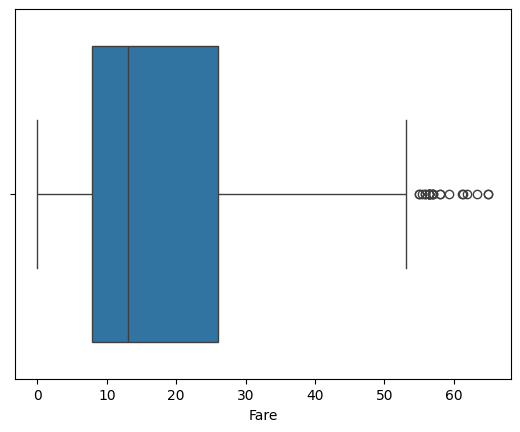

In [31]:
sns.boxplot(x=df['Fare'])

plt.show()

In [32]:
Q1 = df['Fare'].quantile(0.25)

Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  750 non-null    int64  
 1   Survived     750 non-null    int64  
 2   Pclass       750 non-null    int64  
 3   Name         750 non-null    object 
 4   Sex          750 non-null    object 
 5   Age          750 non-null    float64
 6   SibSp        750 non-null    int64  
 7   Parch        750 non-null    int64  
 8   Ticket       750 non-null    object 
 9   Fare         750 non-null    float64
 10  Embarked     750 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 70.3+ KB


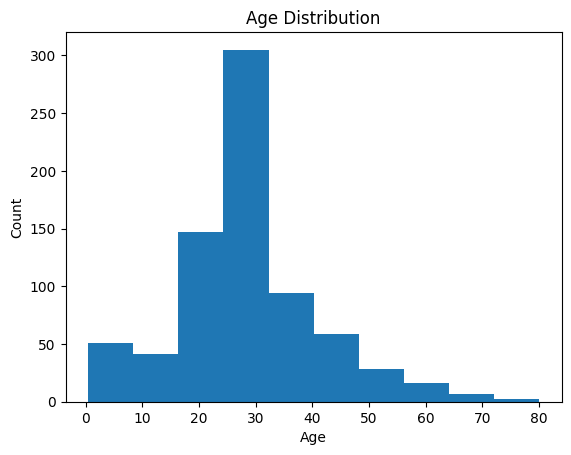

In [34]:
plt.hist(df['Age'])

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

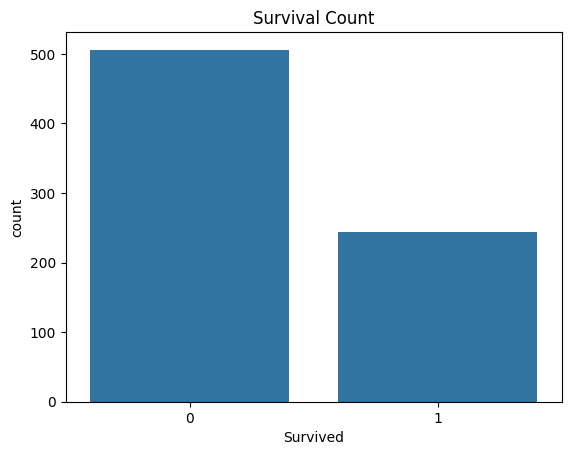

In [35]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()

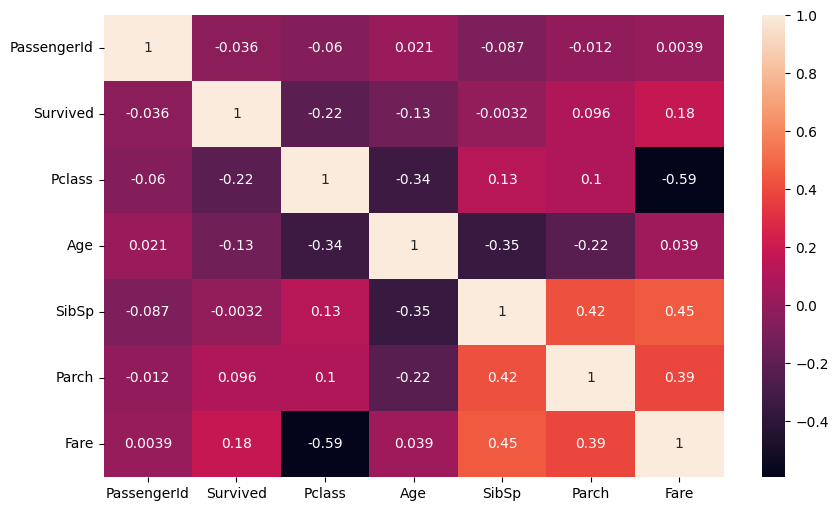

In [36]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True)

plt.show()

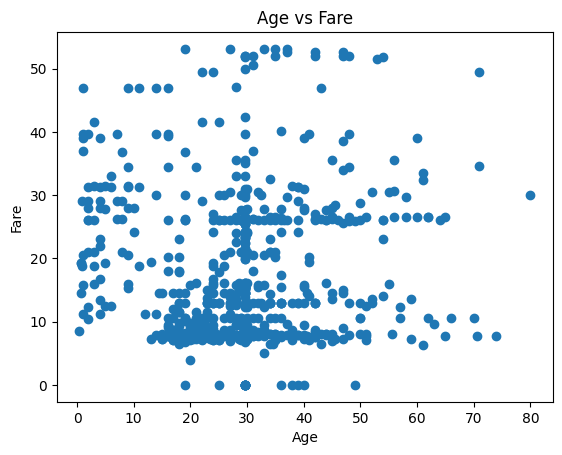

In [37]:
plt.scatter(df['Age'], df['Fare'])

plt.xlabel("Age")

plt.ylabel("Fare")

plt.title("Age vs Fare")

plt.show()

Insights:
1. Most passengers were aged between 20–40.

2. Female passengers survived more.

3. Higher fare passengers had better survival rates.

4. Fare contains some extreme values (outliers).

In [38]:
df.to_csv('cleaned_titanic.csv', index=False)

In [39]:
files.download('cleaned_titanic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>